In [1]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

import matplotlib.pyplot as plt
import numpy as np

In [2]:
from qutip import *
from qutip.core.gates import phasegate, sqrtiswap

In [3]:
N = 10

wc = 5.0 * 2 * np.pi
w1 = 3.0 * 2 * np.pi
w2 = 2.0 * 2 * np.pi

g1 = 0.01 * 2 * np.pi
g2 = 0.0125 * 2 * np.pi

tlist = np.linspace(0, 100, 500)

width = 0.5

# resonant SQRT iSWAP gate
T0_1 = 20
T_gate_1 = (1 * np.pi)/(4 * g1)

# resonant iSWAP gate
T0_2 = 60
T_gate_2 = (2 * np.pi)/(4 * g2)

In [4]:
# cavity operators
a = tensor(destroy(N), qeye(2), qeye(2))
n = a.dag() * a

# operators for qubit 1
sm1 = tensor(qeye(N), destroy(2), qeye(2))
sz1 = tensor(qeye(N), sigmaz(), qeye(2))
n1 = sm1.dag() * sm1

# oeprators for qubit 2
sm2 = tensor(qeye(N), qeye(2), destroy(2))
sz2 = tensor(qeye(N), qeye(2), sigmaz())
n2 = sm2.dag() * sm2

In [5]:
# Hamiltonian using QuTiP
Hc = a.dag() * a
H1 = - 0.5 * sz1
H2 = - 0.5 * sz2
Hc1 = g1 * (a.dag() * sm1 + a * sm1.dag())
Hc2 = g2 * (a.dag() * sm2 + a * sm2.dag())

H = wc * Hc + w1 * H1 + w2 * H2 + Hc1 + Hc2 

In [6]:
H

Quantum object: dims=[[10, 2, 2], [10, 2, 2]], shape=(40, 40), type='oper', dtype=CSR, isherm=True
Qobj data =
[[-15.70796327   0.           0.         ...   0.           0.
    0.        ]
 [  0.          -3.14159265   0.         ...   0.           0.
    0.        ]
 [  0.           0.           3.14159265 ...   0.           0.
    0.        ]
 ...
 [  0.           0.           0.         ... 279.60174617   0.
    0.        ]
 [  0.           0.           0.         ...   0.         285.88493148
    0.        ]
 [  0.           0.           0.         ...   0.           0.
  298.45130209]]

In [7]:
# initial state: start with one of the qubits in its excited state
psi0 = tensor(basis(N,0),basis(2,1),basis(2,0))

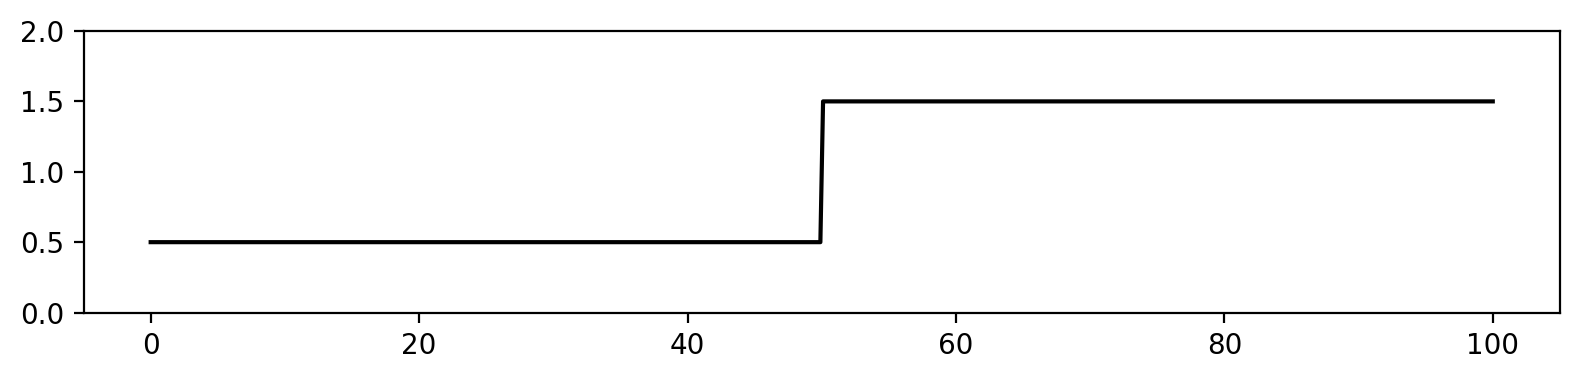

In [8]:

def step_t(w1, w2, t0, width, t):
    """
    Step function that goes from w1 to w2 at time t0
    as a function of t. 
    """
    return w1 + (w2 - w1) * (t > t0)


fig, axes = plt.subplots(1, 1, figsize=(8,2))
axes.plot(tlist, [step_t(0.5, 1.5, 50, 0.0, t) for t in tlist], 'k')
axes.set_ylim(0, 2)
fig.tight_layout()

In [9]:
def wc_t(t, args=None):
    return wc

def w1_t(t, args=None):
    return w1 + step_t(0.0, wc-w1, T0_1, width, t) - step_t(0.0, wc-w1, T0_1+T_gate_1, width, t)

def w2_t(t, args=None):
    return w2 + step_t(0.0, wc-w2, T0_2, width, t) - step_t(0.0, wc-w2, T0_2+T_gate_2, width, t)


H_t = [[Hc, wc_t], [H1, w1_t], [H2, w2_t], Hc1+Hc2]

In [10]:
res = mesolve(H_t, psi0, tlist, [], [])

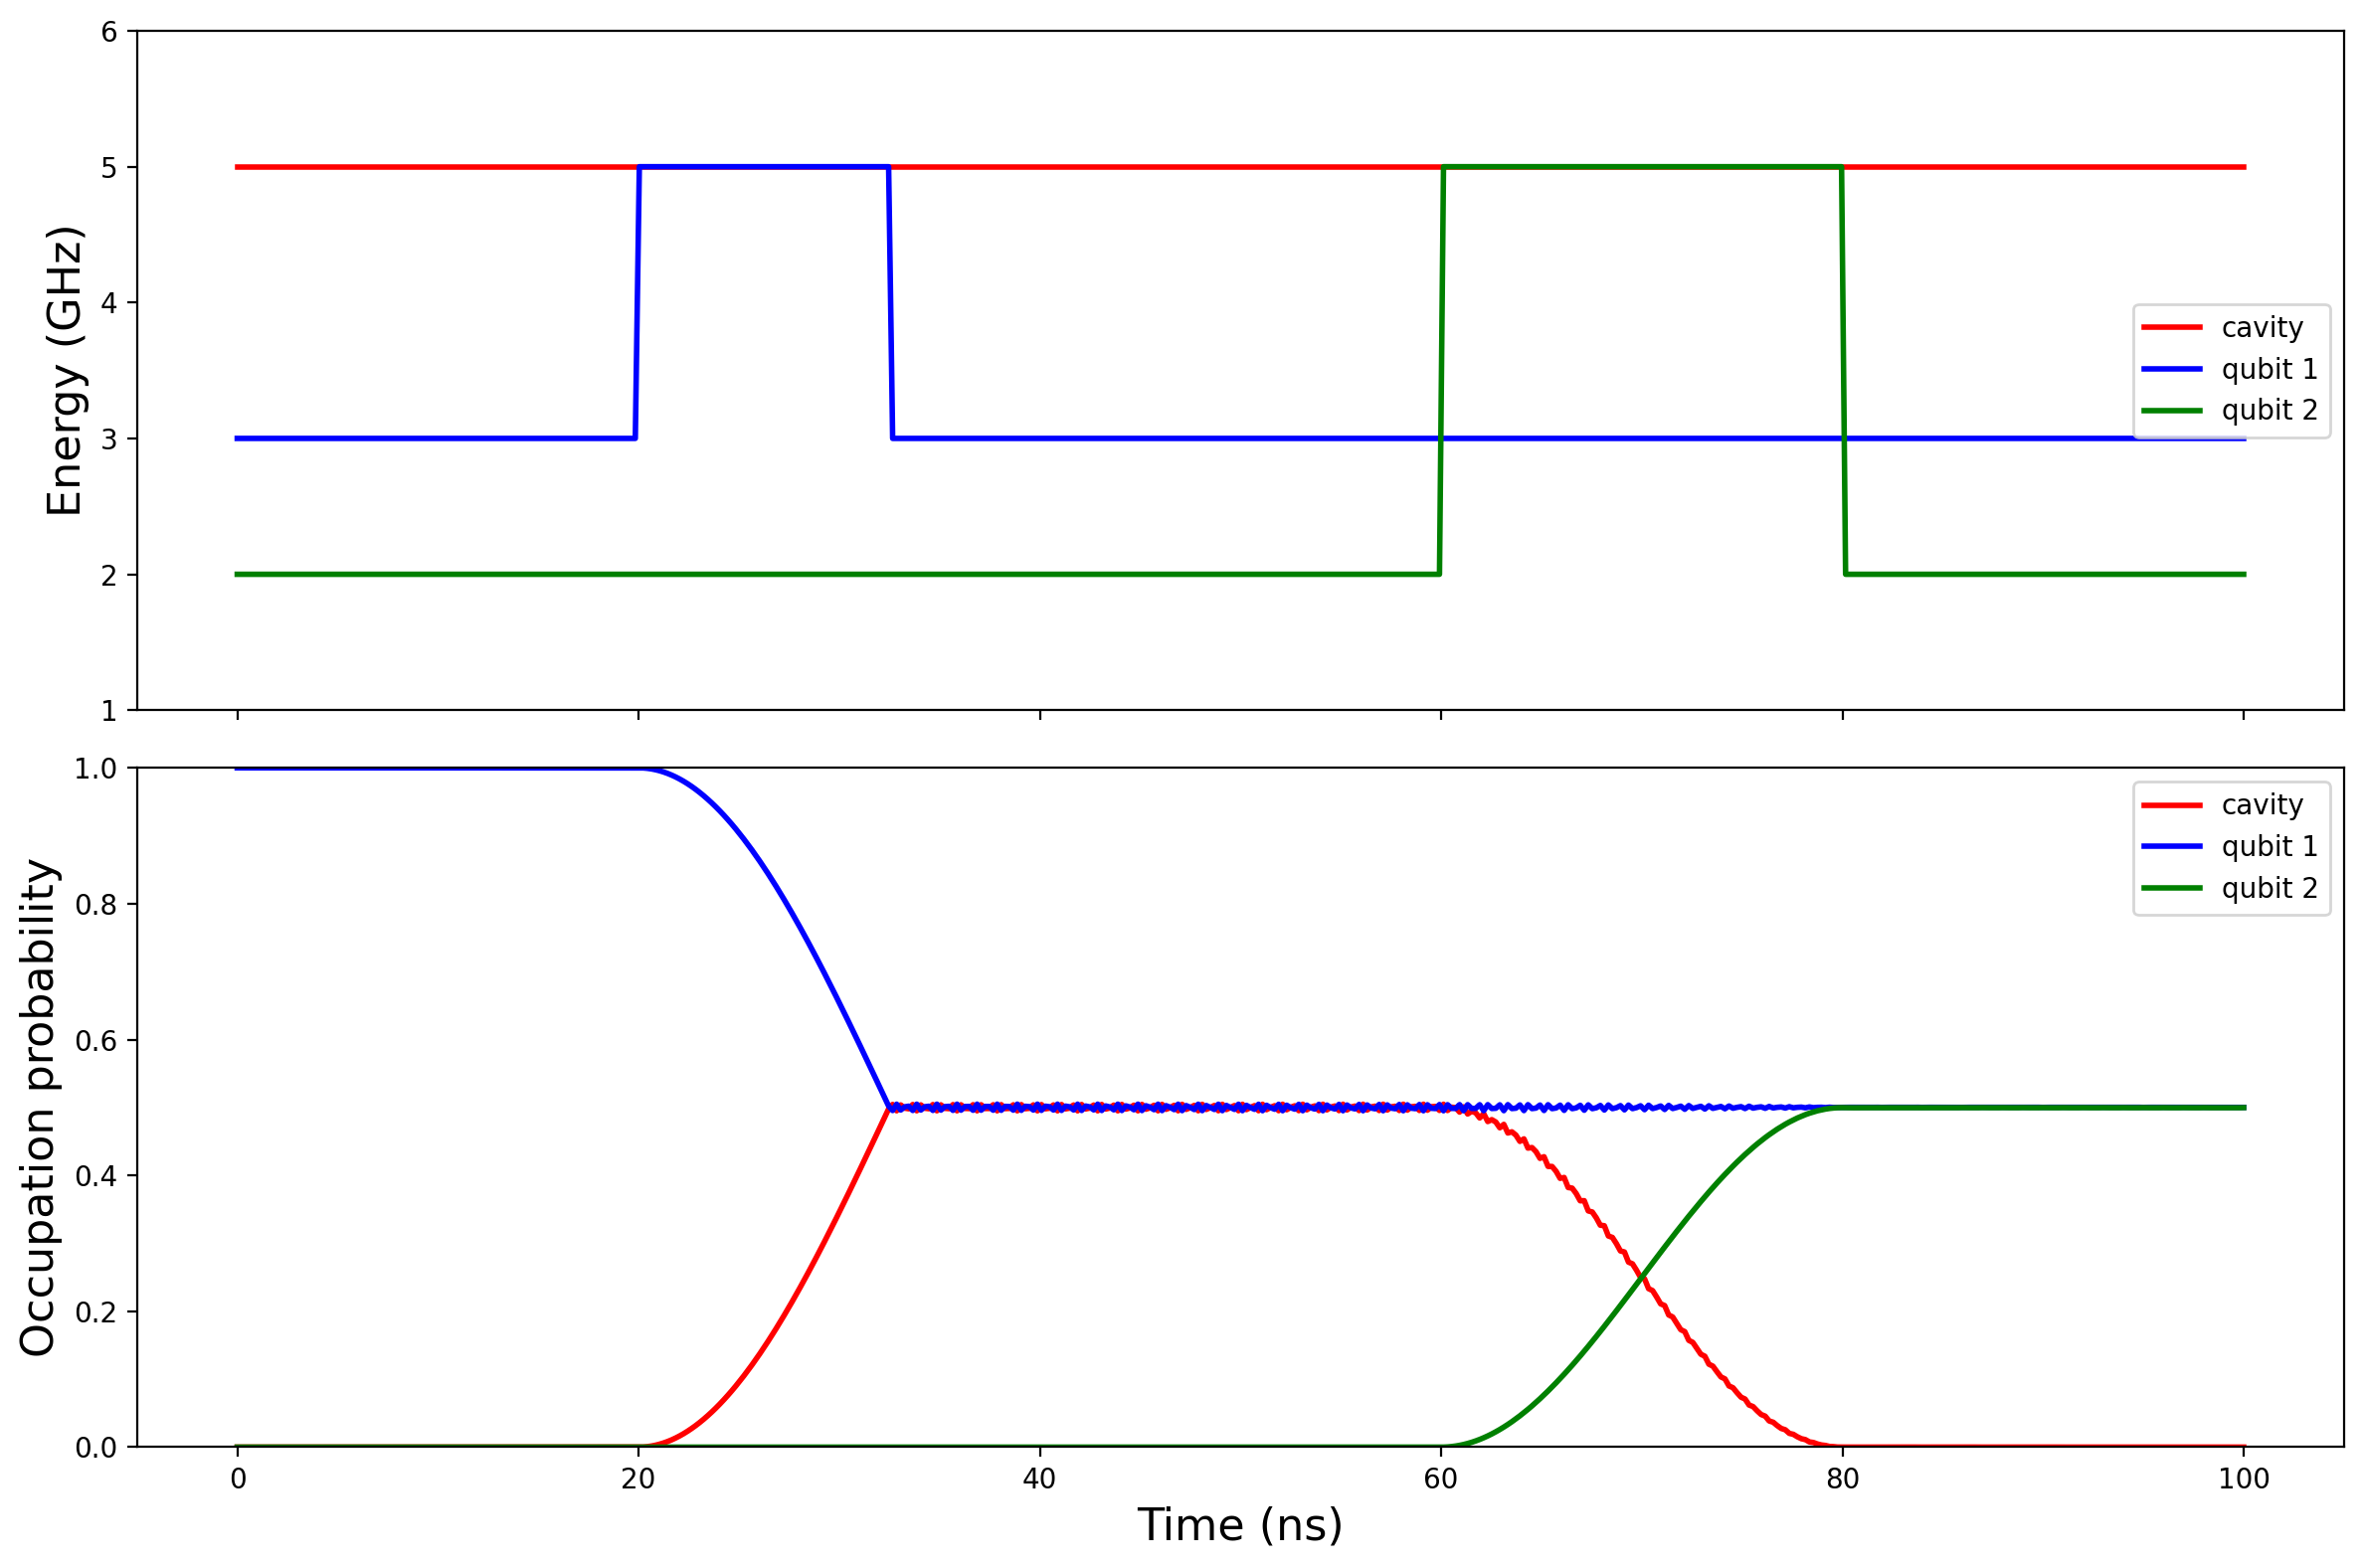

In [11]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(12,8))

axes[0].plot(tlist, np.array(list(map(wc_t, tlist))) / (2*np.pi), 'r', linewidth=2, label="cavity")
axes[0].plot(tlist, np.array(list(map(w1_t, tlist))) / (2*np.pi), 'b', linewidth=2, label="qubit 1")
axes[0].plot(tlist, np.array(list(map(w2_t, tlist))) / (2*np.pi), 'g', linewidth=2, label="qubit 2")
axes[0].set_ylim(1, 6)
axes[0].set_ylabel("Energy (GHz)", fontsize=16)
axes[0].legend()

axes[1].plot(tlist, np.real(expect(n, res.states)), 'r', linewidth=2, label="cavity")
axes[1].plot(tlist, np.real(expect(n1, res.states)), 'b', linewidth=2, label="qubit 1")
axes[1].plot(tlist, np.real(expect(n2, res.states)), 'g', linewidth=2, label="qubit 2")
axes[1].set_ylim(0, 1)

axes[1].set_xlabel("Time (ns)", fontsize=16)
axes[1].set_ylabel("Occupation probability", fontsize=16)
axes[1].legend()

fig.tight_layout()

In [12]:

# extract the final state from the result of the simulation
rho_final = res.states[-1]

# trace out the resonator mode and print the two-qubit density matrix
rho_qubits = ptrace(rho_final, [1,2])
rho_qubits

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 6.16909641e-05+0.j         0.00000000e+00+0.j
   0.00000000e+00+0.j         0.00000000e+00+0.j       ]
 [ 0.00000000e+00+0.j         4.99792760e-01+0.j
  -4.99575076e-01+0.0198461j  0.00000000e+00+0.j       ]
 [ 0.00000000e+00+0.j        -4.99575076e-01-0.0198461j
   5.00145549e-01+0.j         0.00000000e+00+0.j       ]
 [ 0.00000000e+00+0.j         0.00000000e+00+0.j
   0.00000000e+00+0.j         0.00000000e+00+0.j       ]]

In [13]:
# compare to the ideal result of the sqrtiswap gate (plus phase correction) for the current initial state
rho_qubits_ideal = ket2dm(tensor(phasegate(0), phasegate(-np.pi/2)) * sqrtiswap() * tensor(basis(2,1), basis(2,0)))
rho_qubits_ideal

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.  0.  0.  0. ]
 [0.  0.5 0.5 0. ]
 [0.  0.5 0.5 0. ]
 [0.  0.  0.  0. ]]

In [14]:
fidelity(rho_qubits, rho_qubits_ideal)

0.01985140900499033

### **Only two qubits interacting**

In [15]:
w1 = 40 * 2 * np.pi
w2 = 2 * 2 * np.pi

g = 0.1 * 2 * np.pi

tlist = np.linspace(0, 60, 501)

width = 0.01

# resonant SQRT iSWAP gate
T0_1 = 20
T_gate_1 = (1 * np.pi)/(4 * g)


In [16]:
# operators for qubit 1
sm1 = tensor(destroy(2), qeye(2))
sz1 = tensor(sigmaz(), qeye(2))
n1 = sm1.dag() * sm1

# oeprators for qubit 2
sm2 = tensor(qeye(2), destroy(2))
sz2 = tensor(qeye(2), sigmaz())
n2 = sm2.dag() * sm2

In [17]:
# Hamiltonian using QuTiP

H1 = - 0.5 * sz1
H2 = - 0.5 * sz2
Hc = g * (sm1.dag() * sm2 + sm1 * sm2.dag())

H = w1*H1 + w2*H2 + Hc 

H

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
Qobj data =
[[-131.94689145    0.            0.            0.        ]
 [   0.         -119.38052084    0.62831853    0.        ]
 [   0.            0.62831853  119.38052084    0.        ]
 [   0.            0.            0.          131.94689145]]

In [18]:
# initial state: start with one of the qubits in its excited state
psi0 = tensor(basis(2,1),basis(2,0))

In [19]:
psi0

Quantum object: dims=[[2, 2], [1, 1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]
 [1.]
 [0.]]

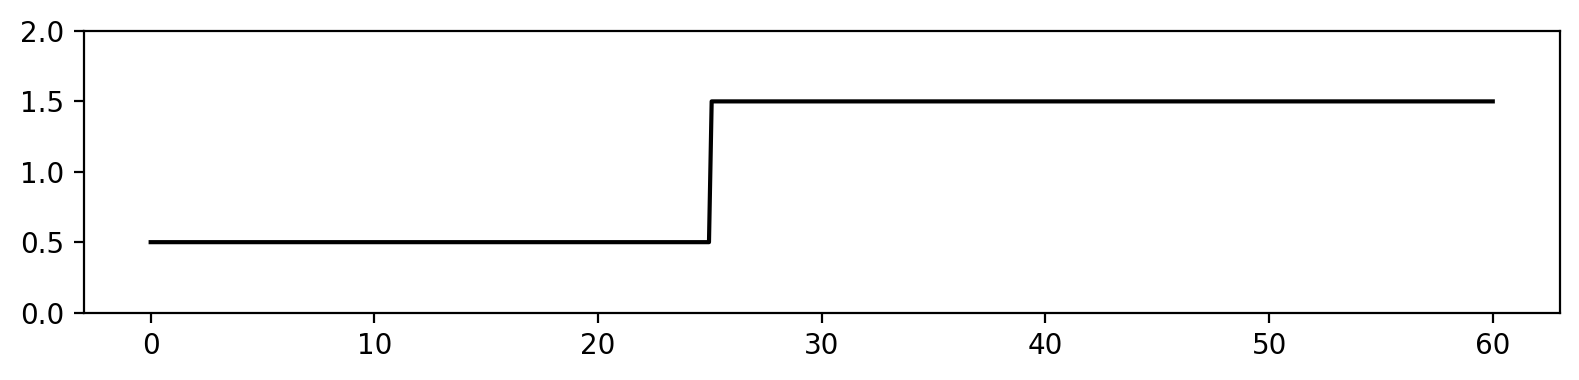

In [20]:
def step_t(w1, w2, t0, width, t):
    """
    Step function that goes from w1 to w2 at time t0
    as a function of t. 
    """
    return w1 + (w2 - w1) * (t > t0)


fig, axes = plt.subplots(1, 1, figsize=(8,2))
axes.plot(tlist, [step_t(0.5, 1.5, 25, 0.0, t) for t in tlist], 'k')
axes.set_ylim(0, 2)
fig.tight_layout()

In [21]:
def w1_t(t, args=None):
    return w1

def w2_t(t, args=None):
    return w2 - step_t(0.0, w2-w1, T0_1, width, t) + step_t(0.0, w2-w1, T0_1+T_gate_1, width, t)


H_t = [[H1, w1_t], [H2, w2_t], Hc]

In [22]:
res = mesolve(H_t, psi0, tlist, [], [])

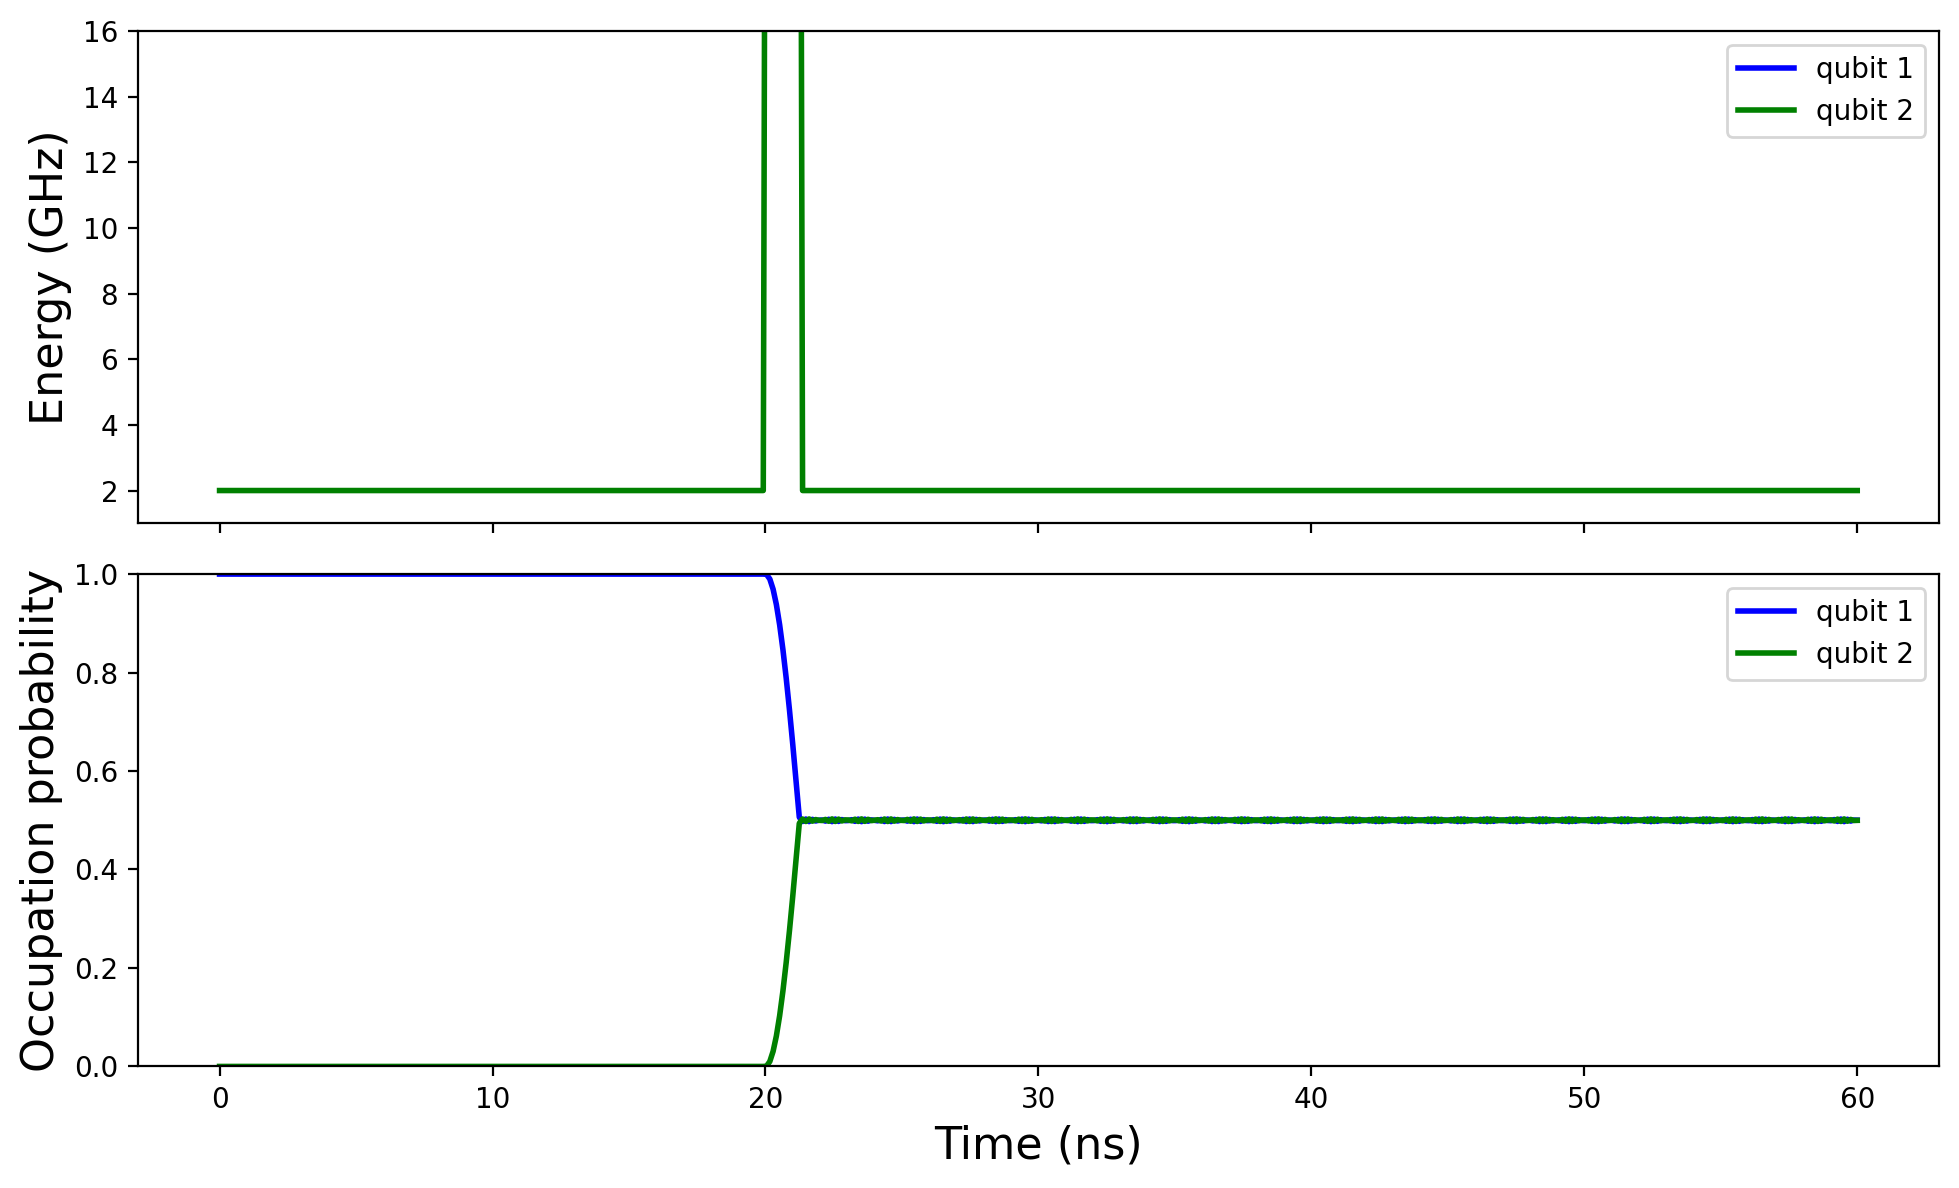

In [23]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10,6))

axes[0].plot(tlist, np.array(list(map(w1_t, tlist))) / (2*np.pi), 'b', linewidth=2, label="qubit 1")
axes[0].plot(tlist, np.array(list(map(w2_t, tlist))) / (2*np.pi), 'g', linewidth=2, label="qubit 2")
axes[0].set_ylim(1, 16)
axes[0].set_ylabel("Energy (GHz)", fontsize=16)
axes[0].legend()

axes[1].plot(tlist, np.real(expect(n1, res.states)), 'b', linewidth=2, label="qubit 1")
axes[1].plot(tlist, np.real(expect(n2, res.states)), 'g', linewidth=2, label="qubit 2")
axes[1].set_ylim(0, 1)

axes[1].set_xlabel("Time (ns)", fontsize=16)
axes[1].set_ylabel("Occupation probability", fontsize=16)
axes[1].legend()

fig.tight_layout()

In [24]:

# extract the final state from the result of the simulation
rho_final = res.states[-1]

# trace out the resonator mode and print the two-qubit density matrix
rho_qubits = rho_final * rho_final.dag()
rho_qubits

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.        +0.00000000e+00j  0.        +0.00000000e+00j
   0.        +0.00000000e+00j  0.        +0.00000000e+00j]
 [ 0.        +0.00000000e+00j  0.49979531+1.23279943e-18j
  -0.06888412+4.95232204e-01j  0.        +0.00000000e+00j]
 [ 0.        +0.00000000e+00j -0.06888412-4.95232204e-01j
   0.50020469-2.37987916e-18j  0.        +0.00000000e+00j]
 [ 0.        +0.00000000e+00j  0.        +0.00000000e+00j
   0.        +0.00000000e+00j  0.        +0.00000000e+00j]]

In [25]:
# compare to the ideal result of the sqrtiswap gate (plus phase correction) for the current initial state
rho_qubits_ideal = ket2dm(tensor(phasegate(0), phasegate(-np.pi/2)) * sqrtiswap() * tensor(basis(2,1), basis(2,0)))
rho_qubits_ideal

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.  0.  0.  0. ]
 [0.  0.5 0.5 0. ]
 [0.  0.5 0.5 0. ]
 [0.  0.  0.  0. ]]

In [26]:
fidelity(rho_qubits, rho_qubits_ideal)

0.6565941496511539

In [27]:
flist = []
for i in range(20):
    # extract the final state from the result of the simulation
    rho_final = res.states[-i - 1]

    # trace out the resonator mode and print the two-qubit density matrix
    rho_qubits = rho_final * rho_final.dag()
    rho_qubits
    flist.append(fidelity(rho_qubits, rho_qubits_ideal))

Text(0, 0.5, 'fidelity')

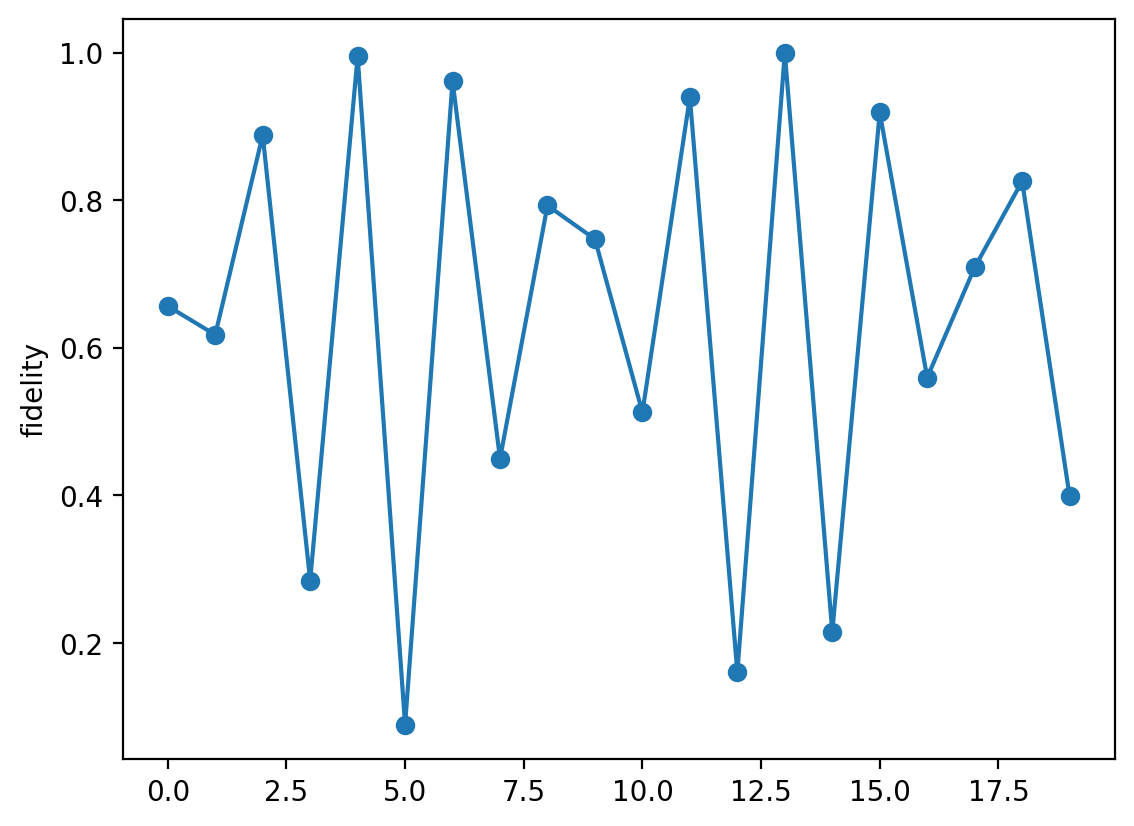

In [28]:
plt.plot(flist, "-o")
plt.ylabel("fidelity")

In [29]:
concurrence(rho_qubits)

0.9999946523054152

### **Finite pulse rise time**

/var/folders/td/3yk470mj5p931p9dtkk0y6jw0000gn/T/ipykernel_43627/336866531.py:7: RuntimeWarning: overflow encountered in exp
  return w1 + (w2 - w1) / (1 + np.exp(-(t-t0)/width))


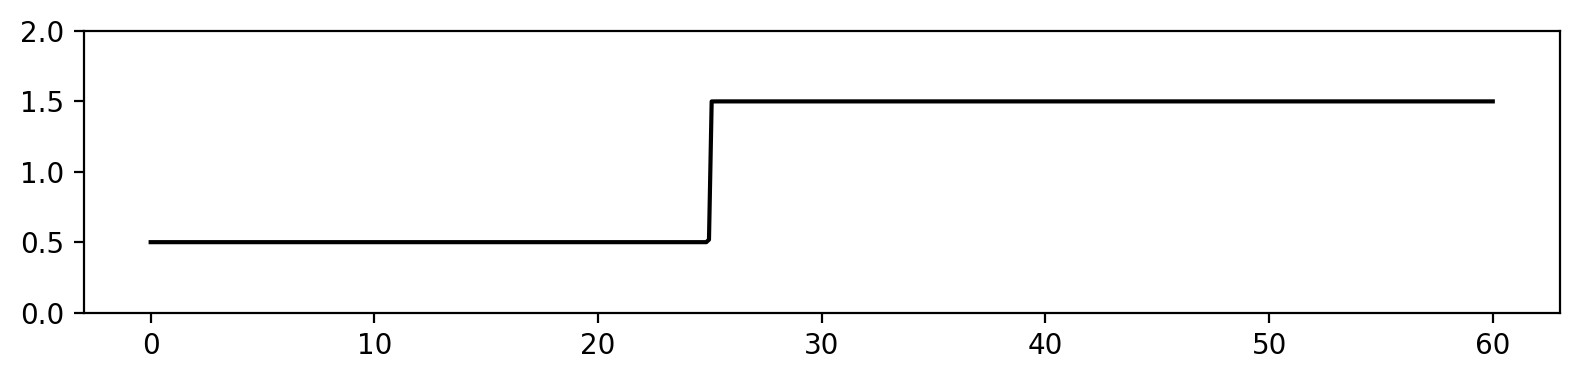

In [30]:
def step_t(w1, w2, t0, width, t):
    """
    Step function that goes from w1 to w2 at time t0
    as a function of t, with finite rise time defined
    by the parameter width.
    """
    return w1 + (w2 - w1) / (1 + np.exp(-(t-t0)/width))


fig, axes = plt.subplots(1, 1, figsize=(8,2))
axes.plot(tlist, [step_t(0.5, 1.5, 25, width, t) for t in tlist], 'k')
axes.set_ylim(0, 2)
fig.tight_layout()

In [31]:
res = mesolve(H_t, psi0, tlist, [], [])

/var/folders/td/3yk470mj5p931p9dtkk0y6jw0000gn/T/ipykernel_43627/336866531.py:7: RuntimeWarning: overflow encountered in exp
  return w1 + (w2 - w1) / (1 + np.exp(-(t-t0)/width))


/var/folders/td/3yk470mj5p931p9dtkk0y6jw0000gn/T/ipykernel_43627/336866531.py:7: RuntimeWarning: overflow encountered in exp
  return w1 + (w2 - w1) / (1 + np.exp(-(t-t0)/width))


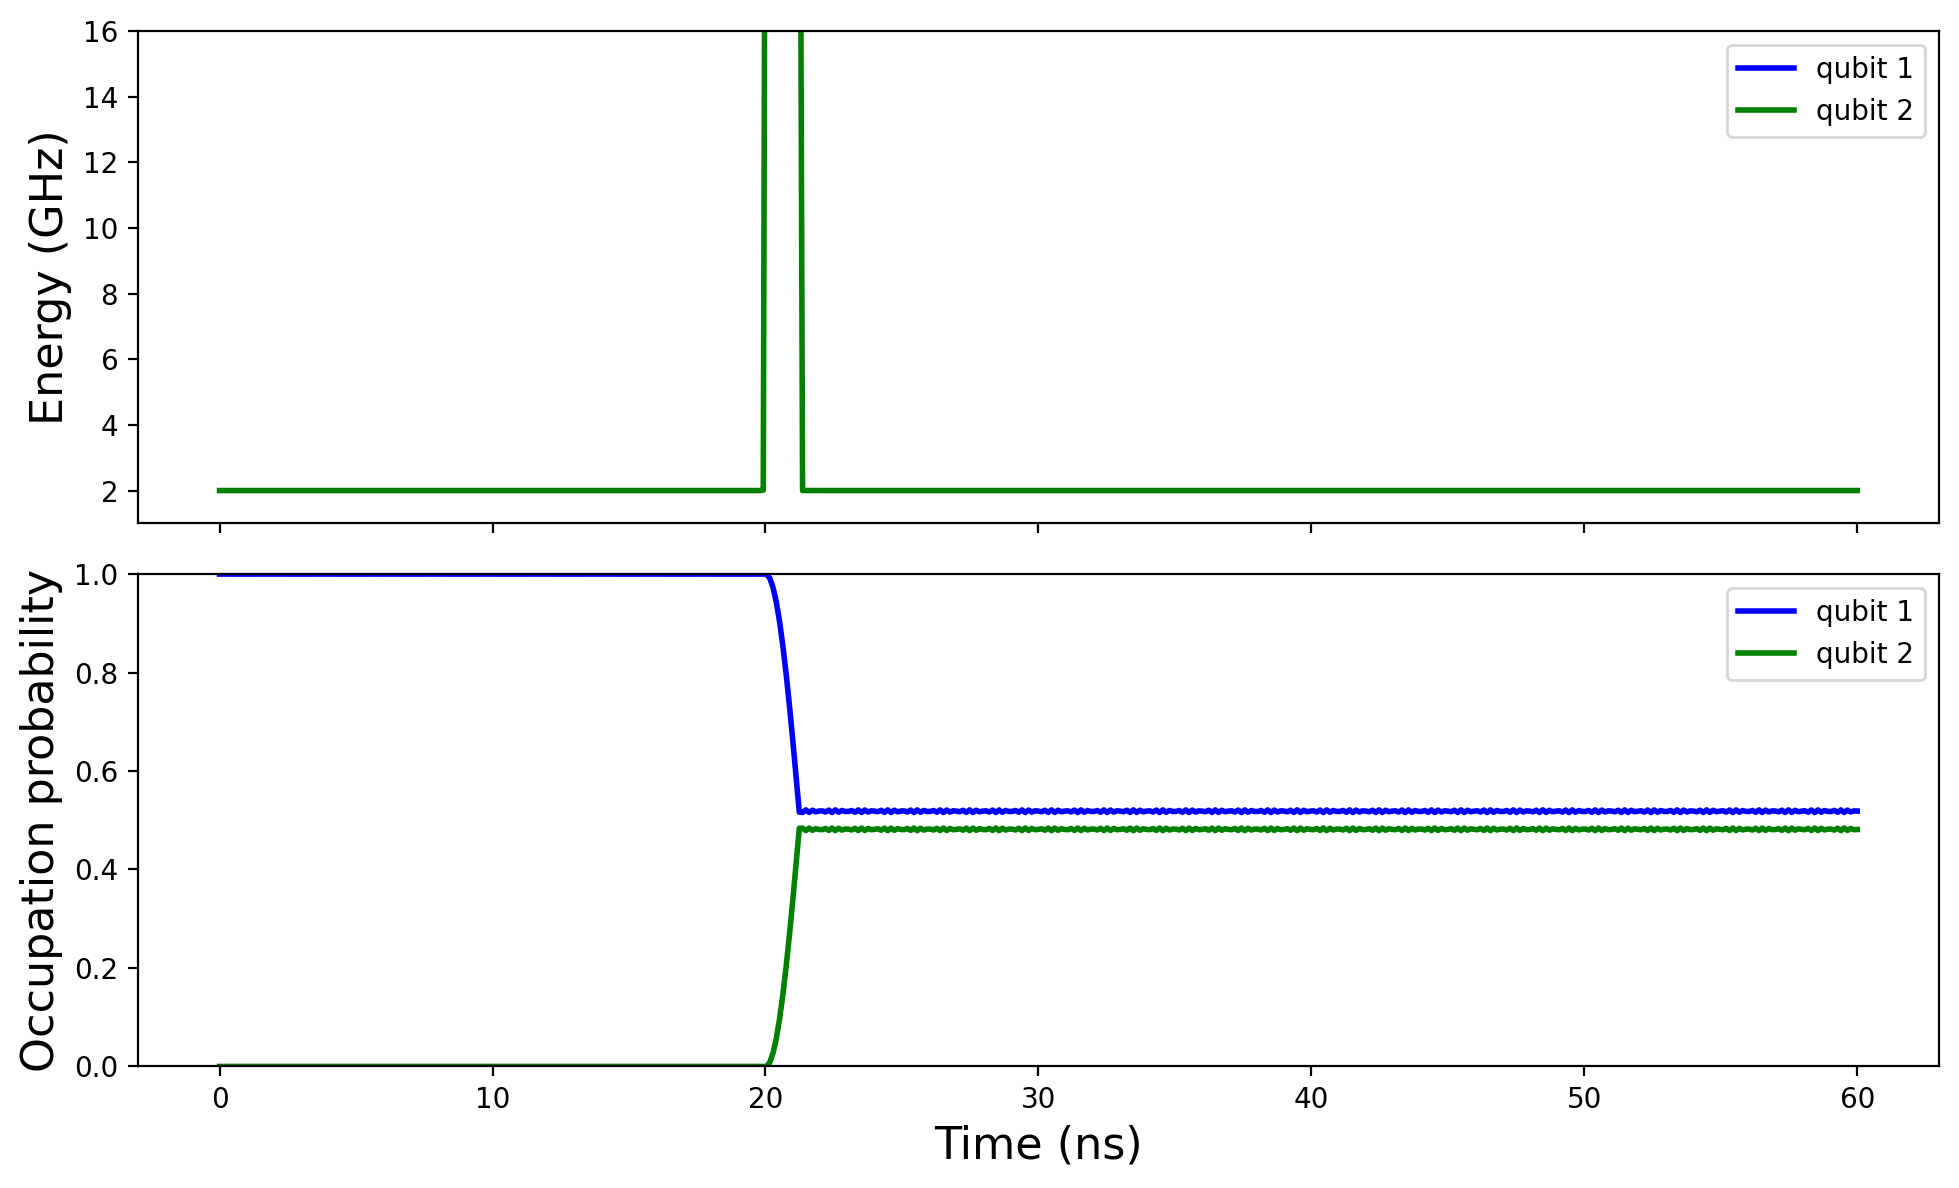

In [32]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10,6))

axes[0].plot(tlist, np.array(list(map(w1_t, tlist))) / (2*np.pi), 'b', linewidth=2, label="qubit 1")
axes[0].plot(tlist, np.array(list(map(w2_t, tlist))) / (2*np.pi), 'g', linewidth=2, label="qubit 2")
axes[0].set_ylim(1, 16)
axes[0].set_ylabel("Energy (GHz)", fontsize=16)
axes[0].legend()

axes[1].plot(tlist, np.real(expect(n1, res.states)), 'b', linewidth=2, label="qubit 1")
axes[1].plot(tlist, np.real(expect(n2, res.states)), 'g', linewidth=2, label="qubit 2")
axes[1].set_ylim(0, 1)

axes[1].set_xlabel("Time (ns)", fontsize=16)
axes[1].set_ylabel("Occupation probability", fontsize=16)
axes[1].legend()

fig.tight_layout()